### Checking if log odds ratio distributions are better modeled as Gaussian or double Gaussian... or triple Gaussian?

In [93]:
import os
import sys
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import minimize
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

# Display NumPy arrays with fixed-point formatting (no scientific notation).
np.set_printoptions(formatter={"float_kind": lambda x: f"{x:.2f}"})

# Make src importable whether cwd is repo root or scripts/
cwd = os.getcwd()
if os.path.basename(cwd) == "scripts":
    repo_root = os.path.abspath(os.path.join(cwd, ".."))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Using src path: {src_path}")

# Import the module from src/
import odds_ratio_test as ort

# Define paths to data and results directories
# odds_ratio_results = os.path.join("..", "results/odds_ratio_test/")
odds_ratio_results = "~/kelvin-scratch/random_bootstrap_test/Results_Mar21/"

Using src path: /Users/calvin/orb-selection/src


Define functions

In [94]:
def gauss_fun(x, mu, sigma):
    """Gaussian function."""
    amp = np.sqrt(2 * np.pi * sigma**2)
    return np.exp(-((x - mu) ** 2) / (2 * sigma**2)) / amp

In [95]:
def gausslogl(x, mu, sigma):
    """Calculate the log-likelihood of a Gaussian distribution."""
    p = gauss_fun(x, mu, sigma)
    return np.nansum(np.log(p), axis=0)

In [96]:
def dgauss_fun(params, x):
    """Double Gaussian function."""
    mu1, mu2, sigma1, sigma2, w = params

    gauss1 = gauss_fun(x, mu1, sigma1)
    gauss2 = gauss_fun(x, mu2, sigma2)
    return w * gauss1 + (1 - w) * gauss2


def dgausslogl(params, x):
    """Calculate the log-likelihood of a double Gaussian distribution."""
    p = dgauss_fun(params, x)
    return -np.nansum(np.log(p), axis=0)

In [97]:
def tgauss_fun(params, x):
    """Triple Gaussian function."""
    w1, mu1, sigma1, w2, mu2, sigma2, mu3, sigma3 = params

    gauss1 = gauss_fun(x, mu1, sigma1)
    gauss2 = gauss_fun(x, mu2, sigma2)
    gauss3 = gauss_fun(x, mu3, sigma3)
    return w1 * gauss1 + w2 * gauss2 + (1 - w1 - w2) * gauss3


def tgausslogl(params, x):
    """Calculate the log-likelihood of a triple Gaussian distribution."""
    p = tgauss_fun(params, x)
    return -np.nansum(np.log(p), axis=0)

In [98]:
def qgauss_fun(params, x):
    """Quadruple Gaussian function."""
    w1, mu1, sigma1, w2, mu2, sigma2, w3, mu3, sigma3, mu4, sigma4 = params

    gauss1 = gauss_fun(x, mu1, sigma1)
    gauss2 = gauss_fun(x, mu2, sigma2)
    gauss3 = gauss_fun(x, mu3, sigma3)
    gauss4 = gauss_fun(x, mu4, sigma4)
    return w1 * gauss1 + w2 * gauss2 + w3 * gauss3 + (1 - w1 - w2 - w3) * gauss4


def qgausslogl(params, x):
    """Calculate the log-likelihood of a quadruple Gaussian distribution."""
    p = qgauss_fun(params, x)
    return -np.nansum(np.log(p), axis=0)

In [99]:
def param_optimization(data, params0_double, params0_triple, params0_quadruple, method='Nelder-Mead'):
    """Optimize parameters for Gaussian mixture models."""

    def _fit(logl_fun, x0, constraints=None):
        kwargs = {"fun": logl_fun, "x0": x0, "args": data, "method": method}
        if method == 'COBYLA' and constraints is not None:
            kwargs["constraints"] = constraints
        params = minimize(**kwargs).x
        return params, -logl_fun(params, data)

    mu = np.nanmean(data)
    sigma = np.nanstd(data)
    logL1 = gausslogl(data, mu, sigma)

    params_double, logL2 = _fit(
        dgausslogl,
        params0_double,
        constraints=(
            {"type": "ineq", "fun": lambda p: p[4]},
            {"type": "ineq", "fun": lambda p: 1 - p[4]}
        )
    )

    params_triple, logL3 = _fit(
        tgausslogl,
        params0_triple,
        constraints=(
            {"type": "ineq", "fun": lambda p: p[0]},
            {"type": "ineq", "fun": lambda p: p[3]},
            {"type": "ineq", "fun": lambda p: 1 - p[0] - p[3]}
        )
    )

    params_quadruple, logL4 = _fit(
        qgausslogl,
        params0_quadruple,
        constraints=(
            {"type": "ineq", "fun": lambda p: p[0]},
            {"type": "ineq", "fun": lambda p: p[3]},
            {"type": "ineq", "fun": lambda p: p[6]},
            {"type": "ineq", "fun": lambda p: 1 - p[0] - p[3] - p[6]}
        )
    )

    params = ([mu, sigma], params_double, params_triple, params_quadruple)
    logLs = (logL1, logL2, logL3, logL4)
    return params, logLs

In [100]:
def param_optimization_old(data, params0_double, params0_triple, params0_quadruple):
    """Optimize parameters for Gaussian models using Nelder-Mead."""

    mu = np.nanmean(data)
    sigma = np.nanstd(data)
    params_single = [mu, sigma]
    logL1 = gausslogl(data, mu, sigma)

    params_double = minimize(dgausslogl, params0_double, args=data, method='Nelder-Mead').x
    logL2 = -dgausslogl(params_double, data)

    params_triple = minimize(tgausslogl, params0_triple, args=data, method='Nelder-Mead').x
    logL3 = -tgausslogl(params_triple, data)

    params_quadruple = minimize(qgausslogl, params0_quadruple, args=data, method='Nelder-Mead').x
    logL4 = -qgausslogl(params_quadruple, data)

    params = [params_single, params_double, params_triple, params_quadruple]
    logLs = [logL1, logL2, logL3, logL4]
    return params, logLs

In [101]:
def bic_calc(n, k, logLs):
    """Calculate BIC values and print the best (lowest-BIC) model."""
    bic = np.log(n) * np.asarray(k) - 2 * np.asarray(logLs)

    model_names = ["Single", "Double", "Triple", "Quadruple"]
    best_idx = int(np.argmin(bic))
    print(f"Lowest BIC model: {model_names[best_idx]} ({bic[best_idx]:.2f})")
    return bic


def format_params(values, decimals=2):
    """Recursively round params for clean display."""
    if isinstance(values, np.ndarray):
        return np.round(values, decimals)
    if isinstance(values, (list, tuple)):
        items = [format_params(v, decimals=decimals) for v in values]
        return type(values)(items)
    if isinstance(values, (float, np.floating)):
        return round(float(values), decimals)
    return values

In [158]:
def plot_it(
    data,
    params_double=None,
    params_triple=None,
    params_quadruple=None,
    plot_double=True,
    plot_triple=True,
    plot_quadruple=True,
):
    _, ax = plt.subplots(figsize=(8, 6))

    # Histogram of the true log odds ratios, filtered for occupancy
    sns.histplot(
        data,
        kde=False,
        bins=200,
        stat="density",
        ax=ax,
        legend=False,
        alpha=0.3,
    )

    x = np.linspace(data.min(), data.max(), 100)

    curve_specs = [
        ("Single Gaussian fit", "blue", norm.pdf(x, np.mean(data), np.std(data))),
    ]
    if plot_double and params_double is not None:
        curve_specs.append(("Double Gaussian fit", "red", dgauss_fun(params_double, x)))
    if plot_triple and params_triple is not None:
        curve_specs.append(("Triple Gaussian fit", "orange", tgauss_fun(params_triple, x)))
    if plot_quadruple and params_quadruple is not None:
        curve_specs.append(("Quadruple Gaussian fit", "green", qgauss_fun(params_quadruple, x)))

    for label, color, y in curve_specs:
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, 0, color=color, alpha=0.2)

    ax.axvline(
        x=np.mean(data),
        linestyle="dotted",
        color="blue",
        label="Single Gaussian mean",
    )

    if plot_double and params_double is not None:
        for i, mu in enumerate(params_double[:2]):
            ax.axvline(
                x=mu,
                linestyle="dotted",
                color="red",
                label="Double Gaussian means" if i == 0 else None,
            )

    if plot_triple and params_triple is not None:
        for i, mu in enumerate([params_triple[1], params_triple[4], params_triple[7]]):
            ax.axvline(
                x=mu,
                linestyle="dotted",
                color="orange",
                label="Triple Gaussian means" if i == 0 else None,
            )

    if plot_quadruple and params_quadruple is not None:
        for i, mu in enumerate([params_quadruple[1], params_quadruple[4], params_quadruple[7], params_quadruple[10]]):
            ax.axvline(
                x=mu,
                linestyle="dotted",
                color="green",
                label="Quadruple Gaussian means" if i == 0 else None,
            )

    ax.legend()

Import data

In [103]:
loss_results_all = pd.read_csv(
    str(odds_ratio_results) + "Run1_Loss_LT_50-95/loss_odds_results_all.csv"
)
dup_results_all = pd.read_csv(
    str(odds_ratio_results) + "Run2_Dup_RT_50-98/duplication_odds_results_all.csv"
)
total_occ_arr = loss_results_all["Occupancy"].values
loss_log_odds_ratios = loss_results_all["Log odds ratio"].values
dup_log_odds_ratios = dup_results_all["Log odds ratio"].values

Filter for occupancy thresholds

In [104]:
dup_49_98_lors = ort.occupancy_filter(
    dup_log_odds_ratios, 49, 98, total_occ_arr
)
loss_49_95_lors = ort.occupancy_filter(
    loss_log_odds_ratios, 49, 95, total_occ_arr
)

Check whether duplication distribution is bimodal, trimodal, quadmodal -- Nelder-Mead method

In [139]:
data_loss = loss_49_95_lors
mu = np.nanmean(data_loss)
sigma = np.nanstd(data_loss)
params0_double = [mu - sigma, mu + sigma, sigma, sigma, 0.4]
params0_triple = [0.33, mu - sigma, sigma, 0.33, mu, sigma, mu + sigma, sigma]
# params0_quadruple = [0.5, -1.5, sigma, 0.2, 0, sigma/2, 0.25, 1, sigma, 1.1, sigma]
params0_quadruple = [0.25, -1.5*mu, sigma, 0.25, -0.5*mu, sigma, 0.25, 0.5*mu, sigma, 1.5*mu, sigma]

params_loss_NM, logLs_loss_NM = param_optimization(
    data_loss, params0_double, params0_triple, params0_quadruple
    )

bic_loss_NM = bic_calc(len(data_loss), [2,5,8,11], logLs_loss_NM)

/var/folders/h8/wkfyd5dj3nnd_smftqfplclh0000gn/T/ipykernel_11874/1031113746.py:15: RuntimeWarning: invalid value encountered in log
  return -np.nansum(np.log(p), axis=0)


Lowest BIC model: Quadruple (19755.49)


In [135]:
bic_loss_NM

array([19877.30, 19857.65, 19824.64, 19755.49])

But one of the weights is negative for quadruple: 

In [136]:
format_params(params_loss_NM[3], decimals=2)

array([0.35, 0.36, 1.79, -0.05, -0.00, 5.01, 0.16, -0.23, 0.55, -1.36,
       1.53])

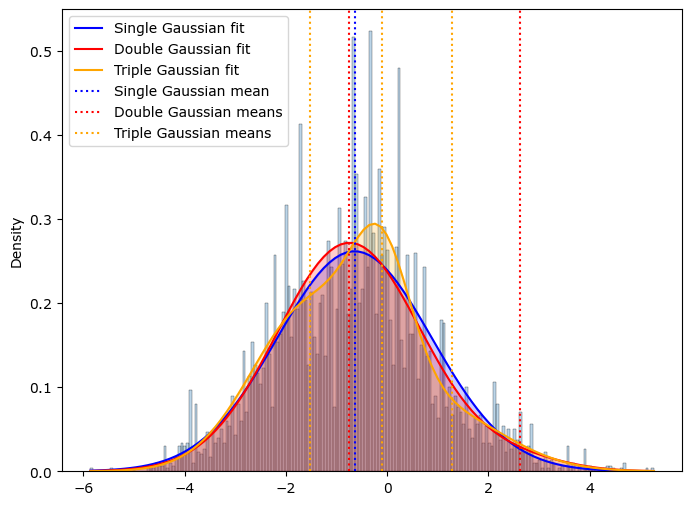

In [138]:
plot_it(data_loss, *params_loss_NM[1:3])

Using constrained optimization with COBYLA:

In [140]:
params_loss_C, logLs_loss_C = param_optimization(
    data_loss, params0_double, params0_triple, params0_quadruple, method='COBYLA'
    )

bic_loss_C = bic_calc(len(data_loss), [2,5,8,11], logLs_loss_C)

/var/folders/h8/wkfyd5dj3nnd_smftqfplclh0000gn/T/ipykernel_11874/3911879491.py:13: RuntimeWarning: invalid value encountered in log
  return -np.nansum(np.log(p), axis=0)
/var/folders/h8/wkfyd5dj3nnd_smftqfplclh0000gn/T/ipykernel_11874/3857916208.py:14: RuntimeWarning: invalid value encountered in log
  return -np.nansum(np.log(p), axis=0)
/var/folders/h8/wkfyd5dj3nnd_smftqfplclh0000gn/T/ipykernel_11874/1031113746.py:15: RuntimeWarning: invalid value encountered in log
  return -np.nansum(np.log(p), axis=0)


Lowest BIC model: Triple (19860.16)


In [110]:
bic_loss_C

array([19877.30, 19863.68, 19860.16, 19920.17])

In [111]:
format_params(params_loss_C[3], decimals=2)

array([0.04, 1.65, 1.67, 0.00, -0.07, 1.22, 0.05, -0.54, 1.67, -0.76,
       1.43])

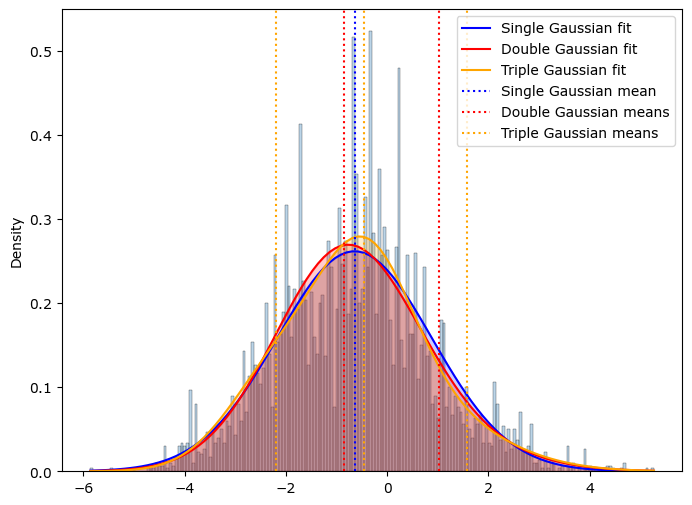

In [175]:
plot_it(data_loss, *params_loss_C[1:3])

Check whether duplication distribution is bimodal, trimodal, quadmodal -- Nelder-Mead

In [143]:
dup_50_98_lors = ort.occupancy_filter(
    dup_log_odds_ratios, 50, 98, total_occ_arr
)

In [161]:
data_dup = dup_49_98_lors
mu = np.nanmean(data_dup)
sigma = np.nanstd(data_dup)
params0_double = [mu - sigma, mu + sigma, sigma, sigma, 0.5]
# params0_triple = [0.3, mu - sigma, sigma/2, 0.4, mu, sigma/2, mu + sigma, sigma/2]
params0_triple = [0.33, mu - sigma, sigma, 0.33, mu, sigma, mu + sigma, sigma]


# params0_quadruple = [0.4, -0.1, sigma/2, 0.5, 0.1, sigma, 0.05, 0.3, sigma, 0.4, sigma]
params0_quadruple = [0.25, -1.5*mu, sigma, 0.25, -0.5*mu, sigma, 0.25, 0.5*mu, sigma, 1.5*mu, sigma]

params_dup_NM, logLs_dup_NM = param_optimization(
    data_dup, params0_double, params0_triple, params0_quadruple,
    )

bic_dup = bic_calc(len(data_dup), [2,5,8,11], logLs_dup_NM)

Lowest BIC model: Double (21987.03)


None are negative in this one

In [147]:
format_params(params_dup_NM[2], decimals=3)

array([0.60, 0.06, 1.11, 0.39, -0.02, 0.61, 0.68, 1.99])

In [148]:
format_params(params_dup_NM[3], decimals=3)

array([0.33, -0.01, 0.59, 0.10, -0.01, 0.98, 0.33, -0.03, 0.98, 0.21,
       1.28])

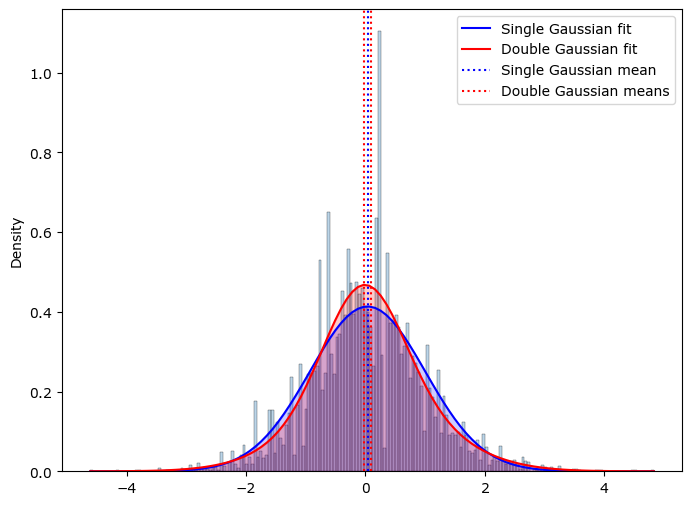

In [167]:
plot_it(data_dup, params_double=params_dup_NM[1], plot_quadruple=False)

With COBYLA method, triple wins: 

In [171]:
data_dup = dup_49_98_lors

params_dup_C, logLs_dup_C = param_optimization(
    data_dup, params0_double, params0_triple, params0_quadruple, method='COBYLA'
    )

bic_dup = bic_calc(len(data_dup), [2,5,8,11], logLs_dup_C)

/var/folders/h8/wkfyd5dj3nnd_smftqfplclh0000gn/T/ipykernel_11874/3911879491.py:13: RuntimeWarning: invalid value encountered in log
  return -np.nansum(np.log(p), axis=0)
/var/folders/h8/wkfyd5dj3nnd_smftqfplclh0000gn/T/ipykernel_11874/3857916208.py:14: RuntimeWarning: invalid value encountered in log
  return -np.nansum(np.log(p), axis=0)


Lowest BIC model: Triple (22013.85)


In [172]:
format_params(params_dup_C[3], decimals=5)

array([0.32, 0.18, 1.24, 0.31, -0.08, 0.94, 0.31, -0.01, 0.59, 0.10, 0.83])

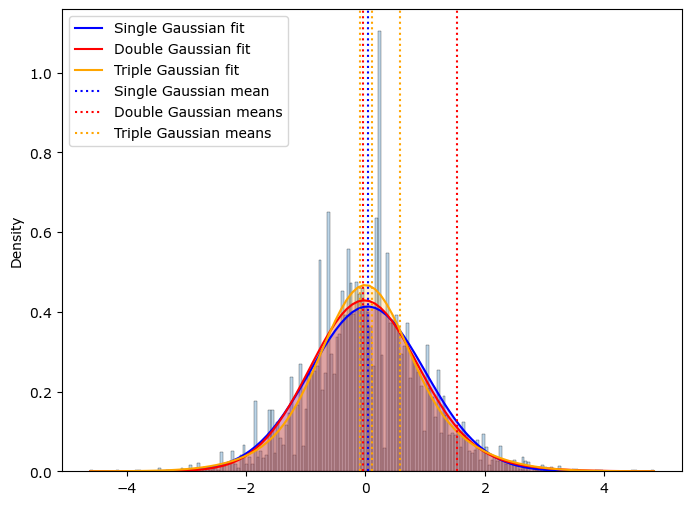

In [176]:
plot_it(data_dup, *params_dup_C[1:3], plot_quadruple=False)

Using occupancy threshold = 75

In [119]:
dup_75_98_lors = ort.occupancy_filter(
    dup_log_odds_ratios, 75, 98, total_occ_arr
)
loss_75_95_lors = ort.occupancy_filter(
    loss_log_odds_ratios, 75, 95, total_occ_arr
)

In [120]:
data_dup = dup_75_98_lors
mu = np.nanmean(data_dup)
sigma = np.nanstd(data_dup)
params0_double = [mu - sigma, mu + sigma, sigma, sigma, 0.5]
params0_triple = [0.33, mu - sigma, sigma, 0.33, mu, sigma, mu + sigma, sigma]
params0_quadruple = [0.25, -1.5*mu, sigma, 0.25, -0.5*mu, sigma, 0.25, 0.5*mu, sigma, 1.5*mu, sigma]

params_dup_C, logLs_dup_C = param_optimization(
    data_dup, params0_double, params0_triple, params0_quadruple, method='COBYLA'
    )

bic_dup = bic_calc(len(data_dup), [2,5,8,11], logLs_dup_C)

/var/folders/h8/wkfyd5dj3nnd_smftqfplclh0000gn/T/ipykernel_11874/3911879491.py:13: RuntimeWarning: invalid value encountered in log
  return -np.nansum(np.log(p), axis=0)
/var/folders/h8/wkfyd5dj3nnd_smftqfplclh0000gn/T/ipykernel_11874/3857916208.py:14: RuntimeWarning: invalid value encountered in log
  return -np.nansum(np.log(p), axis=0)


Lowest BIC model: Double (13249.28)


In [121]:
data_loss = loss_75_95_lors
mu = np.nanmean(data_loss)
sigma = np.nanstd(data_loss)
params0_double = [mu - sigma, mu + sigma, sigma, sigma, 0.5]
params0_triple = [0.33, mu - sigma, sigma, 0.33, mu, sigma, mu + sigma, sigma]
params0_quadruple = [0.25, -1.5*mu, sigma, 0.25, -0.5*mu, sigma, 0.25, 0.5*mu, sigma, 1.5*mu, sigma]

params_loss_C, logLs_loss_C = param_optimization(
    data_loss, params0_double, params0_triple, params0_quadruple, method='COBYLA'
    )

bic_loss = bic_calc(len(data_loss), [2,5,8,11], logLs_loss_C)

/var/folders/h8/wkfyd5dj3nnd_smftqfplclh0000gn/T/ipykernel_11874/3911879491.py:13: RuntimeWarning: invalid value encountered in log
  return -np.nansum(np.log(p), axis=0)
/var/folders/h8/wkfyd5dj3nnd_smftqfplclh0000gn/T/ipykernel_11874/3857916208.py:14: RuntimeWarning: invalid value encountered in log
  return -np.nansum(np.log(p), axis=0)
/var/folders/h8/wkfyd5dj3nnd_smftqfplclh0000gn/T/ipykernel_11874/1031113746.py:15: RuntimeWarning: invalid value encountered in log
  return -np.nansum(np.log(p), axis=0)


Lowest BIC model: Single (9641.08)


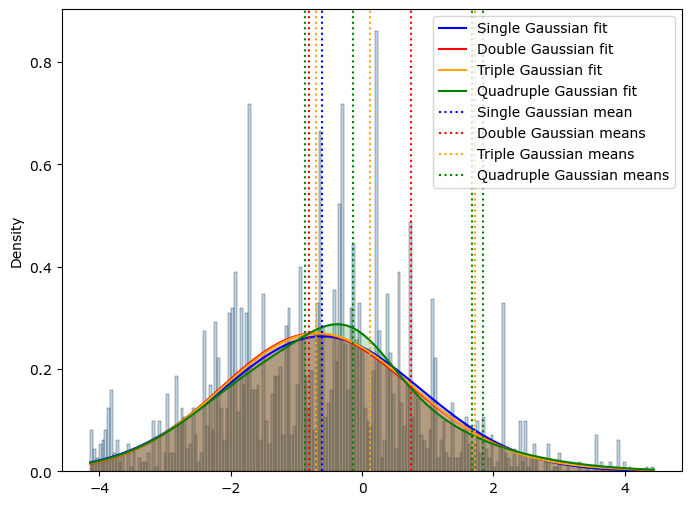

In [122]:
plot_it(data_loss, *params_loss_C[1:4])

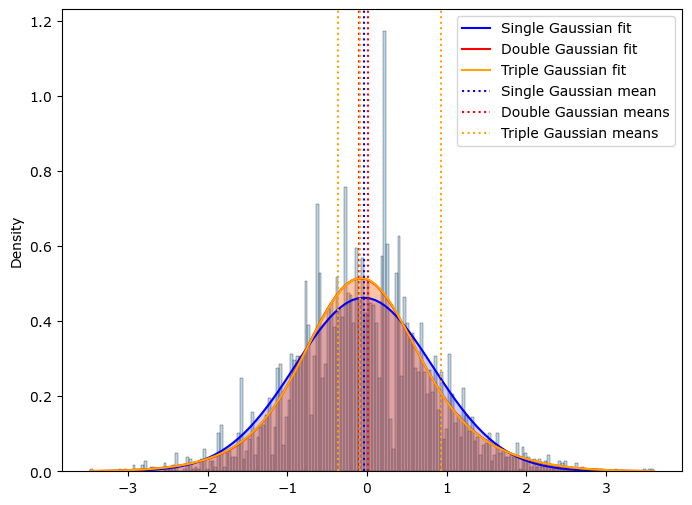

In [123]:
plot_it(data_dup, *params_dup_C[1:3])